In [1]:
# auto reload modified modules
%load_ext autoreload
%autoreload 2
import os
import sys
from pathlib import Path
def _find_repo_root(start):
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "experiments").is_dir():
            return candidate
    return start
CODE_DIR = os.environ.get("ETA_CODE_DIR")
if CODE_DIR is None:
    CODE_DIR = str(_find_repo_root(Path.cwd()))
WORK_DIR = os.environ.get("ETA_WORK_DIR", CODE_DIR)
SRC_DIR = str(Path(CODE_DIR) / "src")
for import_path in (CODE_DIR, SRC_DIR):
    if import_path not in sys.path:
        sys.path.insert(0, import_path)

import numpy as np
import torch 
import torch.nn as nn
from torch.nn import functional as F 
from utils import *
from plot_utils import *
from copy import deepcopy
from tqdm import tqdm
import matplotlib.pyplot as plt 
plot_setting(usetex=False)
seed = 1

### Import Data

In [2]:
n_train = 100
var_in = 10
data_path = WORK_DIR + '/data/toy.pth'
DATA = torch.load(data_path)

# Define a 2D Fourier mode function with amplitude scaling
def fourier_mode_2d(x, freq=(1/6, 1/8), phase=(0, 0), amplitude=0.1):
    """
    Compute a 2D Fourier mode: amplitude * sin(2π*freq_1*x_1 + phase_1) * sin(2π*freq_2*x_2 + phase_2)
    
    Args:
        x: Input tensor of shape [..., 2]
        freq: Tuple of frequencies for each dimension
        phase: Tuple of phase shifts for each dimension
        amplitude: Scaling factor for the output
    
    Returns:
        Tensor of shape [...] with Fourier mode values
    """
    return -amplitude * torch.sin(2 * np.pi * freq[0] * x[..., 0] + phase[0]) * \
                        torch.sin(2 * np.pi * freq[1] * x[..., 1] + phase[1])

X = DATA['X_all']
U1 = DATA['Y_all'].reshape(-1,1)
U2 = fourier_mode_2d(X).reshape(-1, 1)
U = torch.cat((U1,U2), dim=1)
GRIDS = DATA['in_grid']
N = int(np.sqrt(GRIDS.shape[0]))
U1_GRID = DATA['out_grid'].reshape((N,N))
U2_GRID = fourier_mode_2d(GRIDS).reshape((N, N))

x_train = DATA['x_train']
u1_train = DATA['y_train'].reshape(-1,1)
u2_train = fourier_mode_2d(x_train).reshape(-1,1)
u_train = torch.cat((u1_train,u2_train),1)

X1 = GRIDS[:,0].reshape((N,N))
X2 = GRIDS[:,1].reshape((N,N))
n_train = x_train.shape[0]

# observable
def y(u):
    return 2*torch.abs(u[:,0]) + 0.5*torch.abs(u[:,1])
Y = y(U)

### Output PDF

In [3]:
from kde import get_data_pdf
y_true, py_true, y_true_pdf = get_data_pdf(Y, Y, None)

### Import NN and Training and Testing Wrappers


In [4]:
from train_utils import train_nn
from models import FCNN
from test_utils import *

### MSE-Loss NN

In [5]:
global_seed(1)
dimensions = [
    256,256,256
]
activation = 'psilu'
indim = 2
outdim = 2
init = 'xavier normal'
loss_fun = nn.MSELoss
optim = torch.optim.Adam
epochs = 3000
batch_size = n_train
# opt_params = {
#     'lr' : 3e-4
# }

# train on selected dataset
_device = device('all')
msenn = FCNN(dimensions, activation, indim, outdim, init, False)
msenn = nn.DataParallel(msenn)
mse_res = train_nn(msenn, x_train, u_train, loss_fun,
                   optim, epochs, batch_size, _device)

100%|██████████| 3000/3000 [00:36<00:00, 82.99it/s] 


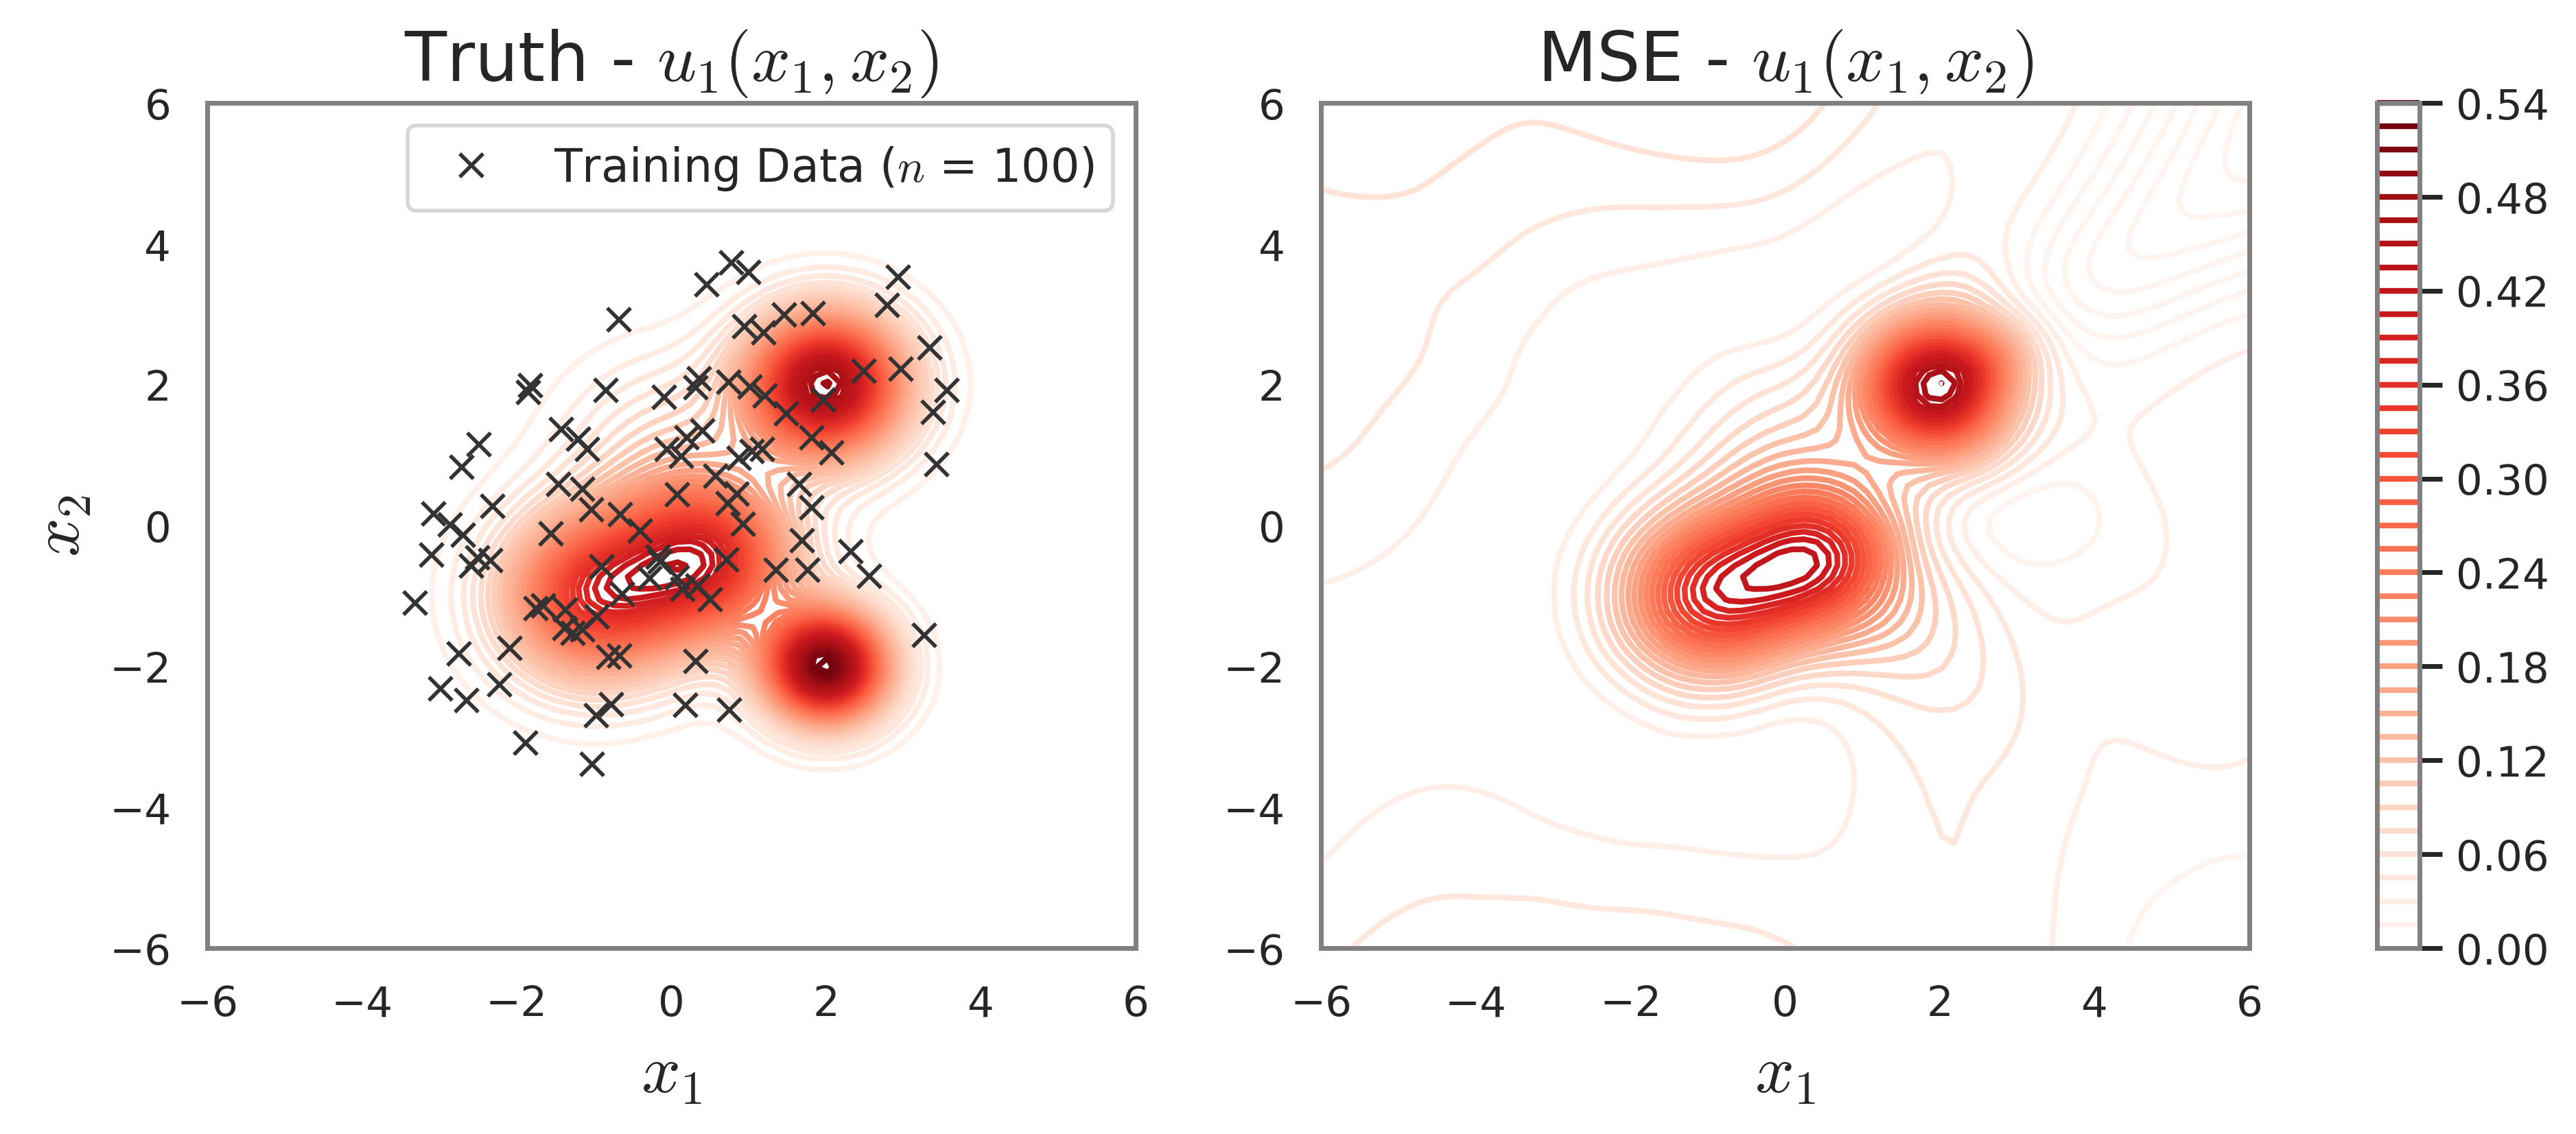

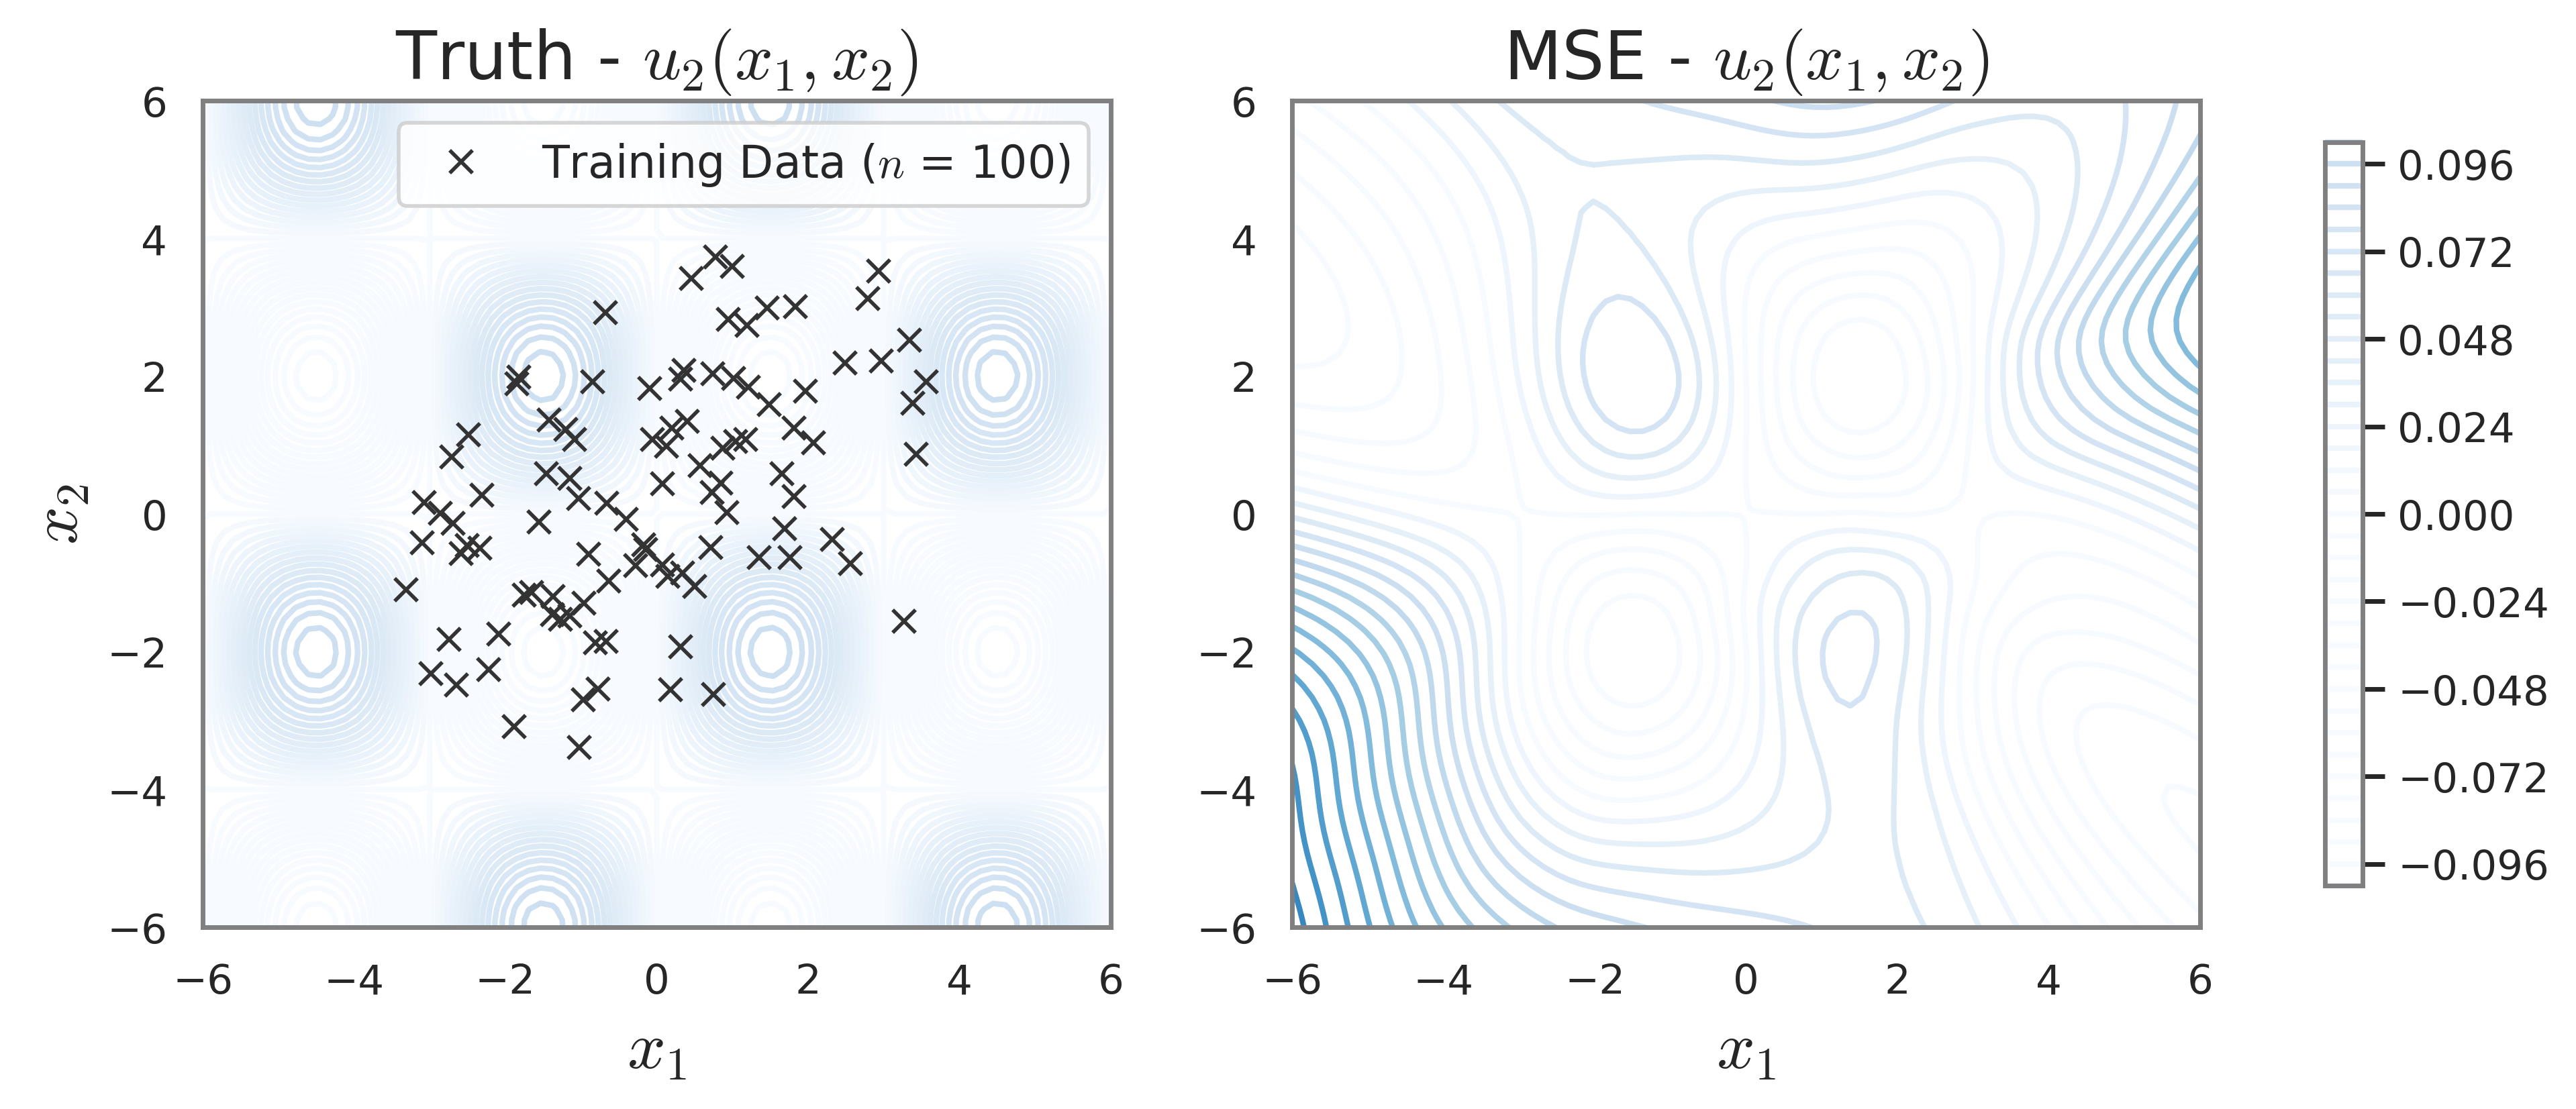

In [6]:
# plot test result
mse_eval_res = eval_result_2d(mse_res, GRIDS, X, y, device=_device)
fig1, ax1 = plt.subplots(1,2,figsize=(12,4), dpi=400)
# Find global min and max for consistent color scale
vmin = 0#min(torch.min(U1_GRID).item(), np.min(mse_eval_res.u1_grid).item())
vmax = max(torch.max(U1_GRID).item(), np.max(mse_eval_res.u1_grid).item())
# Create contour plots with same levels and color scale
contour1 = ax1[0].contour(X1,X2,U1_GRID, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
ax1[0].set_title(r"Truth - $u_1(x_1,x_2)$", fontsize=18)
ax1[0].set_xlabel(r"$x_1$", fontsize=18)
ax1[0].set_ylabel(r"$x_2$", fontsize=18)
ax1[0].plot(x_train[:,0], x_train[:,1], 'x', markersize=6, color='#333333', alpha=1, linewidth=2,
                label=r'Training Data ($n$' + f' = {n_train})')
ax1[0].set_xlim(-6,6)
ax1[0].set_ylim(-6,6)
ax1[0].legend(prop={'size':12})
contour2 = ax1[1].contour(X1,X2,mse_eval_res.u1_grid, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
ax1[1].set_title(r"MSE - $u_1(x_1,x_2)$", fontsize=18)
ax1[1].set_xlabel(r"$x_1$", fontsize=18)
ax1[1].set_xlim(-6,6)
ax1[1].set_ylim(-6,6)
# Add a colorbar that applies to both plots
fig1.colorbar(contour1, ax=ax1, shrink=1)

fig2, ax2 = plt.subplots(1,2,figsize=(12,4), dpi=400)
# Find global min and max for consistent color scale
vmin = 0#min(torch.min(U2_GRID).item(), np.min(mse_eval_res.u2_grid).item())
vmax = max(torch.max(U2_GRID).item(), np.max(mse_eval_res.u2_grid).item())
# Create contour plots with same levels and color scale
contour1 = ax2[0].contour(X1,X2,U2_GRID, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
ax2[0].set_title(r"Truth - $u_2(x_1,x_2)$", fontsize=18)
ax2[0].set_xlabel(r"$x_1$", fontsize=18)
ax2[0].set_ylabel(r"$x_2$", fontsize=18)
ax2[0].plot(x_train[:,0], x_train[:,1], 'x', markersize=6, color='#333333', alpha=1, linewidth=2,
                label=r'Training Data ($n$' + f' = {n_train})')
ax2[0].set_xlim(-6,6)
ax2[0].set_ylim(-6,6)
ax2[0].legend(prop={'size':12})
contour2 = ax2[1].contour(X1,X2,mse_eval_res.u2_grid, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
ax2[1].set_title(r"MSE - $u_2(x_1,x_2)$", fontsize=18)
ax2[1].set_xlabel(r"$x_1$", fontsize=18)
ax2[1].set_xlim(-6,6)
ax2[1].set_ylim(-6,6)
# Add a colorbar that applies to both plots
fig2.colorbar(contour1, ax=ax2, shrink=0.9)

(0.005, 50)

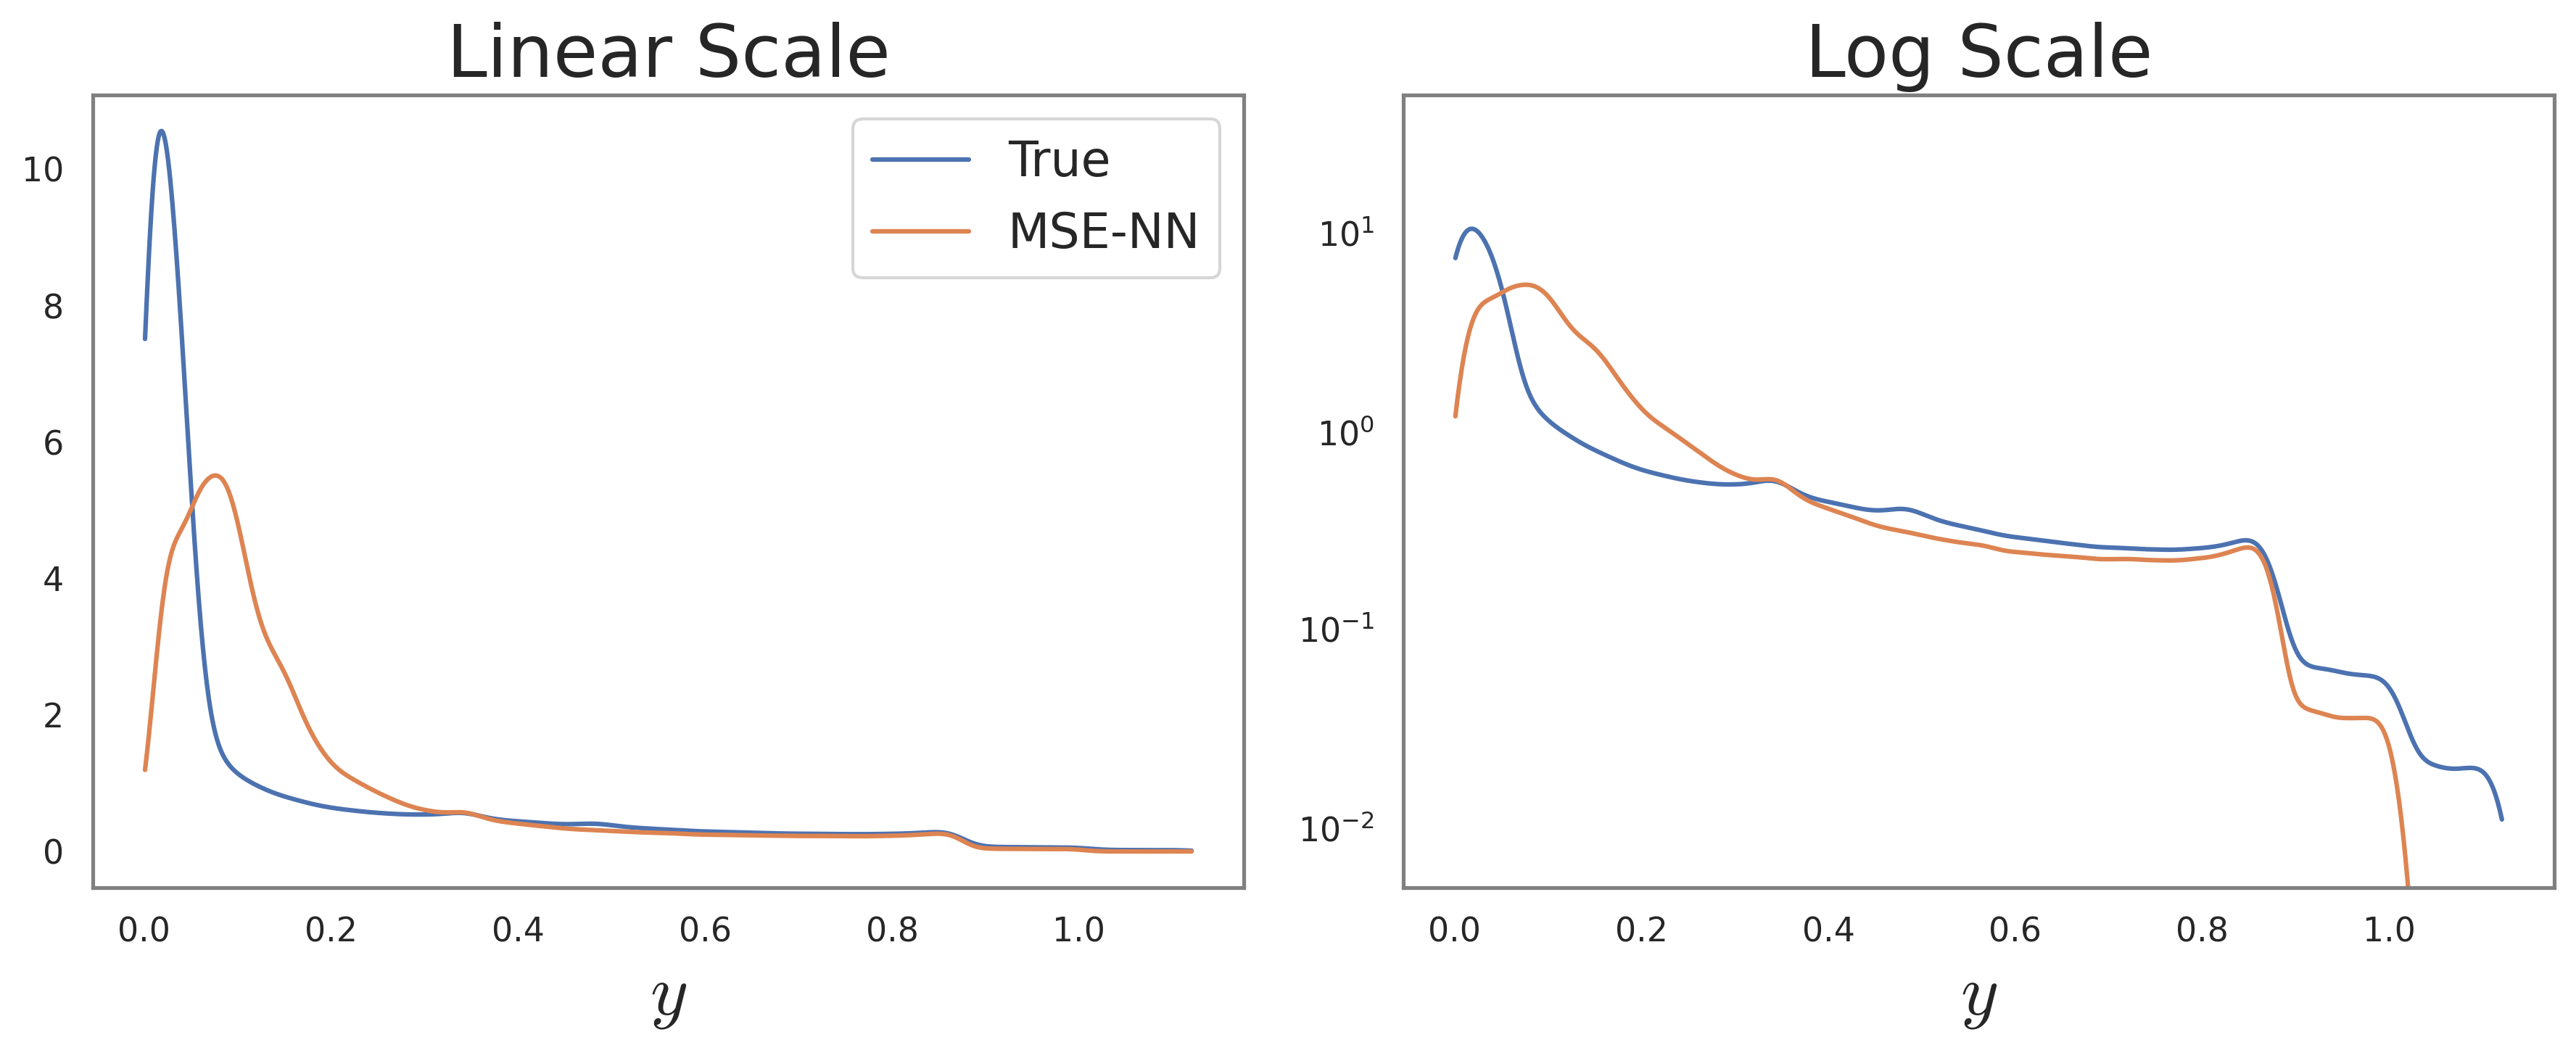

In [7]:
# estimate eta output pdf with KDE
y_mse, py_mse, y_mse_pdf = get_data_pdf(mse_eval_res.y_samples, Y, None)

# plot
fig_mse_pdf, ax_mse_pdf = plot_pdf(y_true, py_true, label="True", title=None)
fig_mse_pdf, ax_mse_pdf = plot_pdf(y_mse, py_mse, label="MSE-NN", fig=fig_mse_pdf, ax=ax_mse_pdf)
fig_mse_pdf.tight_layout()
ax_mse_pdf[1].set_ylim(5e-3, 50)

# plt.savefig(f"./figs/fcnn-pdf-mse-N{n_train}.png")

# Pretraining

In [8]:
from scipy.stats import multivariate_normal
from train_utils import grf_pretrain, train_eta_xuy

def generate_2d_gaussian(seed=42, grid_size=100, domain=(-6, 6), peak_value=0.8, sigma=1.0):
    """
    Generate a 2D Gaussian function with a peak value around 0.8 centered at a random point.
    
    Parameters:
    -----------
    seed : int
        Random seed for reproducibility
    grid_size : int
        Number of grid points in each dimension
    domain : tuple
        Domain range (min, max) for both x1 and x2
    peak_value : float
        The peak value of the Gaussian function
    sigma : float
        Standard deviation of the Gaussian
        
    Returns:
    --------
    numpy.ndarray
        2D array of shape (grid_size, grid_size) containing the function values
    tuple
        The center coordinates (x1_center, x2_center)
    """
    # Set random seed
    np.random.seed(seed)
    
    # Generate random center point
    x1_center = np.random.uniform(domain[0], domain[1])
    x2_center = np.random.uniform(domain[0], domain[1])
    
    # Create grid
    x1 = np.linspace(domain[0], domain[1], grid_size)
    x2 = np.linspace(domain[0], domain[1], grid_size)
    X1, X2 = np.meshgrid(x1, x2)
    
    # Stack coordinates
    pos = np.dstack((X1, X2))
    
    # Create multivariate normal distribution
    rv = multivariate_normal([x1_center, x2_center], sigma * np.eye(2))
    
    # Evaluate pdf on grid
    pdf = rv.pdf(pos)
    
    # Scale to desired peak value
    max_pdf = pdf.max()
    scaled_pdf = pdf * (peak_value / max_pdf)
    
    return torch.from_numpy(scaled_pdf), (x1_center, x2_center)


# $W_1$ Loss

In [9]:
# get quantile points
quantiles = torch.cat((
    torch.linspace(0,0.9,41), torch.linspace(0.9,0.99,21), torch.linspace(0.99,0.999,21), 
    torch.linspace(0.999,0.9999,21), torch.linspace(0.9999,0.99999,21),
    torch.linspace(0.99999,0.999999,21), torch.linspace(0.999999,0.9999999,21)
))

seed :  28


100%|██████████| 3000/3000 [01:58<00:00, 25.38it/s]


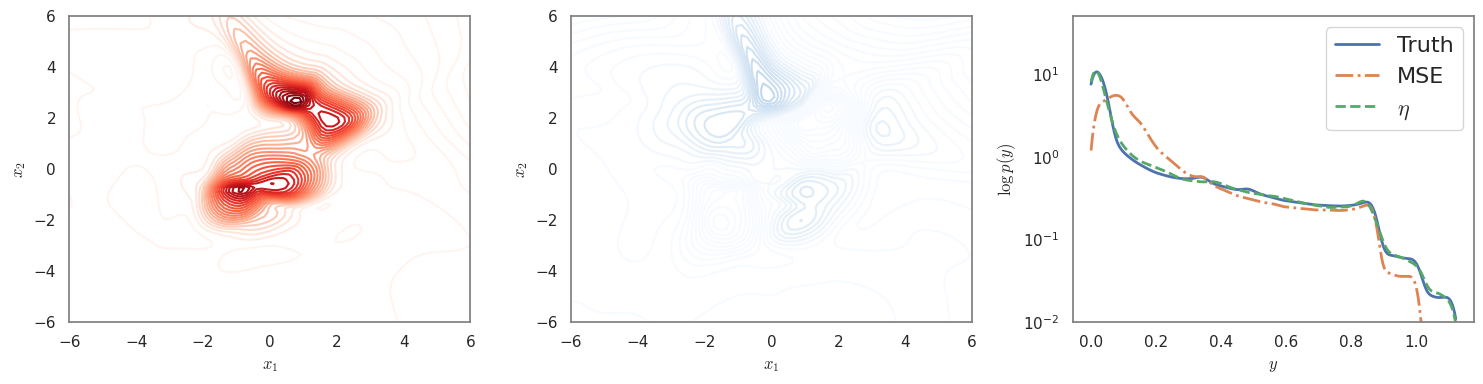

In [ ]:
"""
Multiple runs of eta-learning
"""
# set seed
from models import *
eta_res_list = []
eta_eval_res_list = []
seed_list = [27,28,50,63,64,83]
seed_list = [28]

# quantile loss
quantiles = quantiles
pretrain_epochs = 800
epochs = 4000
batch_size = n_train
_lamb = 1.
omega = 10

# network parameters
n_neurons = 256
dimensions = [
    n_neurons,n_neurons,n_neurons
]
activation = 'psilu'
indim = 2
outdim = 2
init = 'kaiming normal'
loss_fun = nn.MSELoss
optim = torch.optim.Adam
pretrain_u2 = U2_GRID.unsqueeze(-1)

seed = 200
# for k in [range(100)]:
#     seed += 1
for seed in seed_list:
    global_seed(seed)
    print('seed : ', seed)

    # pretraining
    _device = device('all')
    eta_pretrain = FCNN(dimensions, activation, indim, outdim, init, False).to(_device)
    eta_pretrain = nn.DataParallel(eta_pretrain)
    n_grid = 50
    grid_step = 100 // n_grid
    gaussian_field, center = generate_2d_gaussian(seed=seed, sigma=0.3)
    gaussian_field = gaussian_field.unsqueeze(-1)
    pretrain_field = torch.cat((gaussian_field, pretrain_u2), dim=-1)
    pretrain_res = grf_pretrain(pretrain_field, eta_pretrain, pretrain_epochs, n_grid=n_grid, grid_step=grid_step, device=_device)
    pretrain_eval_res = eval_result_2d(pretrain_res, GRIDS, X, y)

    # continual training
    etann = pretrain_res.model
    eta_res = train_eta_xuy(etann, x_train, u_train, X, Y, y, quantiles,
                        optim, epochs, batch_size, _device, _lamb, omega)
    eta_eval_res = eval_result_2d(eta_res, GRIDS, X, y, best_model=True)

    # save results
    eta_res_list.append(eta_res)
    eta_eval_res_list.append(eta_eval_res)
    
    fig, ax = plt.subplots(1,3,figsize=(15,4))
    vmin = 0
    vmax = max(torch.max(U1_GRID).item(), np.max(mse_eval_res.u1_grid).item())
    contour1 = ax[0].contour(X1.numpy(), X2.numpy(), eta_eval_res.u1_grid, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
    ax[0].set_xlim(-6,6)
    ax[0].set_ylim(-6,6)
    ax[0].set_xlabel(r'$x_1$')
    ax[0].set_ylabel(r'$x_2$')

    vmin = 0
    vmax = max(torch.max(U2_GRID).item(), np.max(mse_eval_res.u2_grid).item())
    ax[1].contour(X1.numpy(), X2.numpy(), eta_eval_res.u2_grid, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
    ax[1].set_xlim(-6,6)
    ax[1].set_ylim(-6,6)
    ax[1].set_xlabel(r'$x_1$')
    ax[1].set_ylabel(r'$x_2$')

    y_eta, py_eta, y_eta_pdf = get_data_pdf(eta_eval_res.y_samples, Y, None)
    ax[2].plot(y_true, py_true, linewidth=2, label='Truth')
    ax[2].plot(y_mse, py_mse, '-.', linewidth=2, label='MSE')
    ax[2].plot(y_eta, py_eta, '--', linewidth=2, label=r'$\eta$')
    ax[2].set_yscale('log')
    ax[2].set_xlabel(r'$y$')
    ax[2].set_ylabel(r'$\log p(y)$')
    ax[2].set_ylim(1e-2, 50)
    ax[2].legend(prop={'size': 16})

    fig.tight_layout()
    plt.show()
    plt.close()

    # assert False

seed:  28


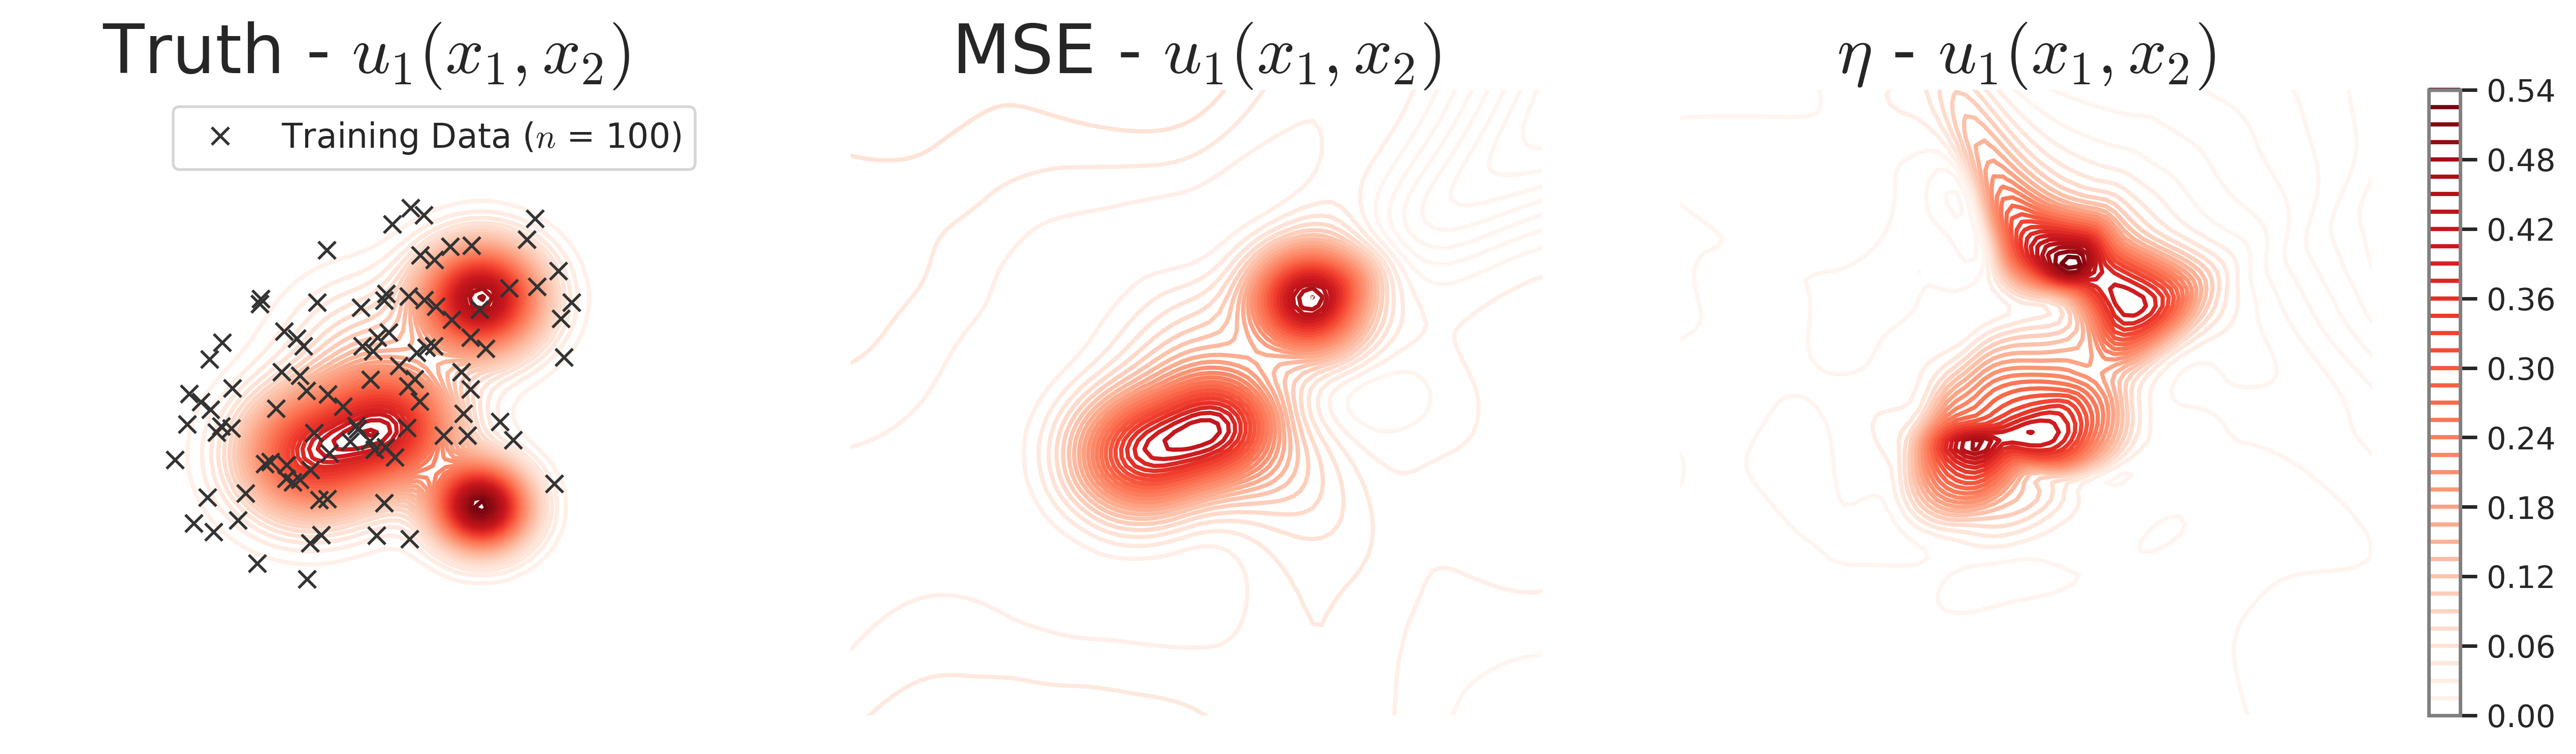

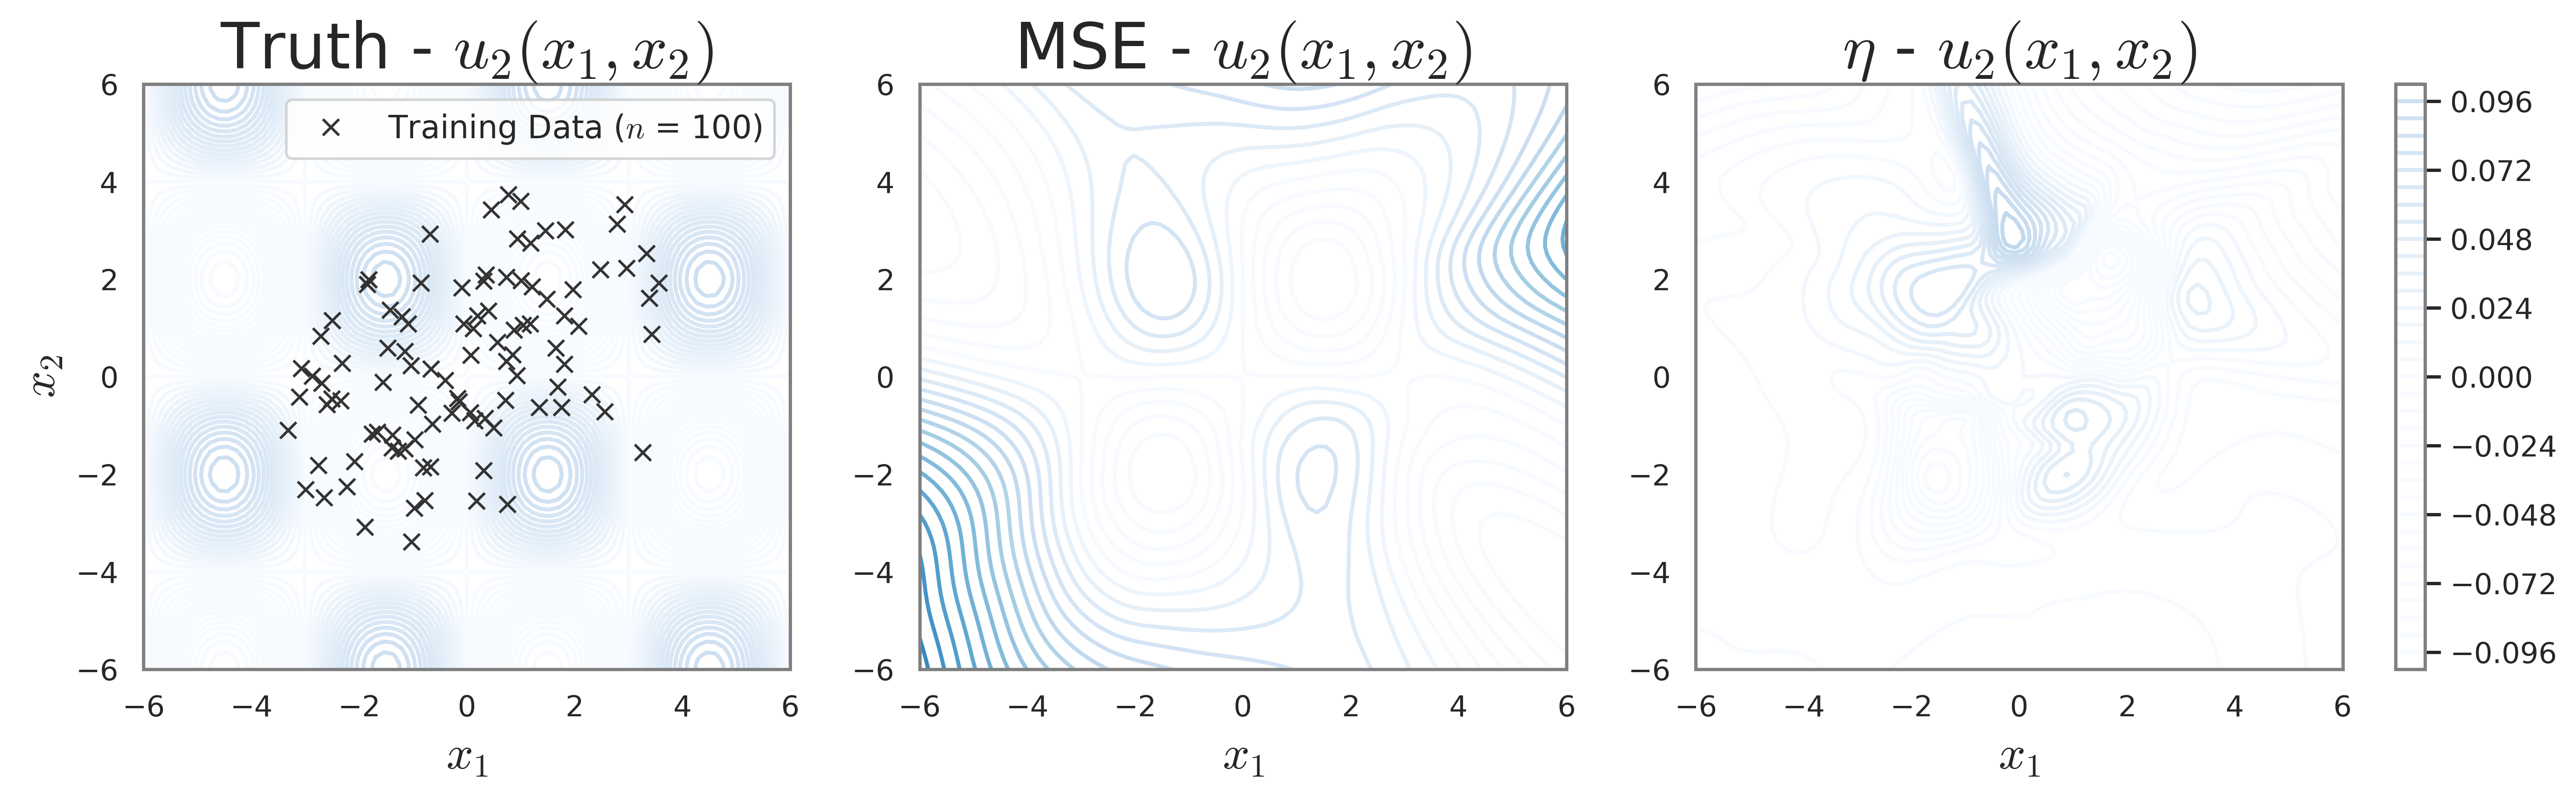

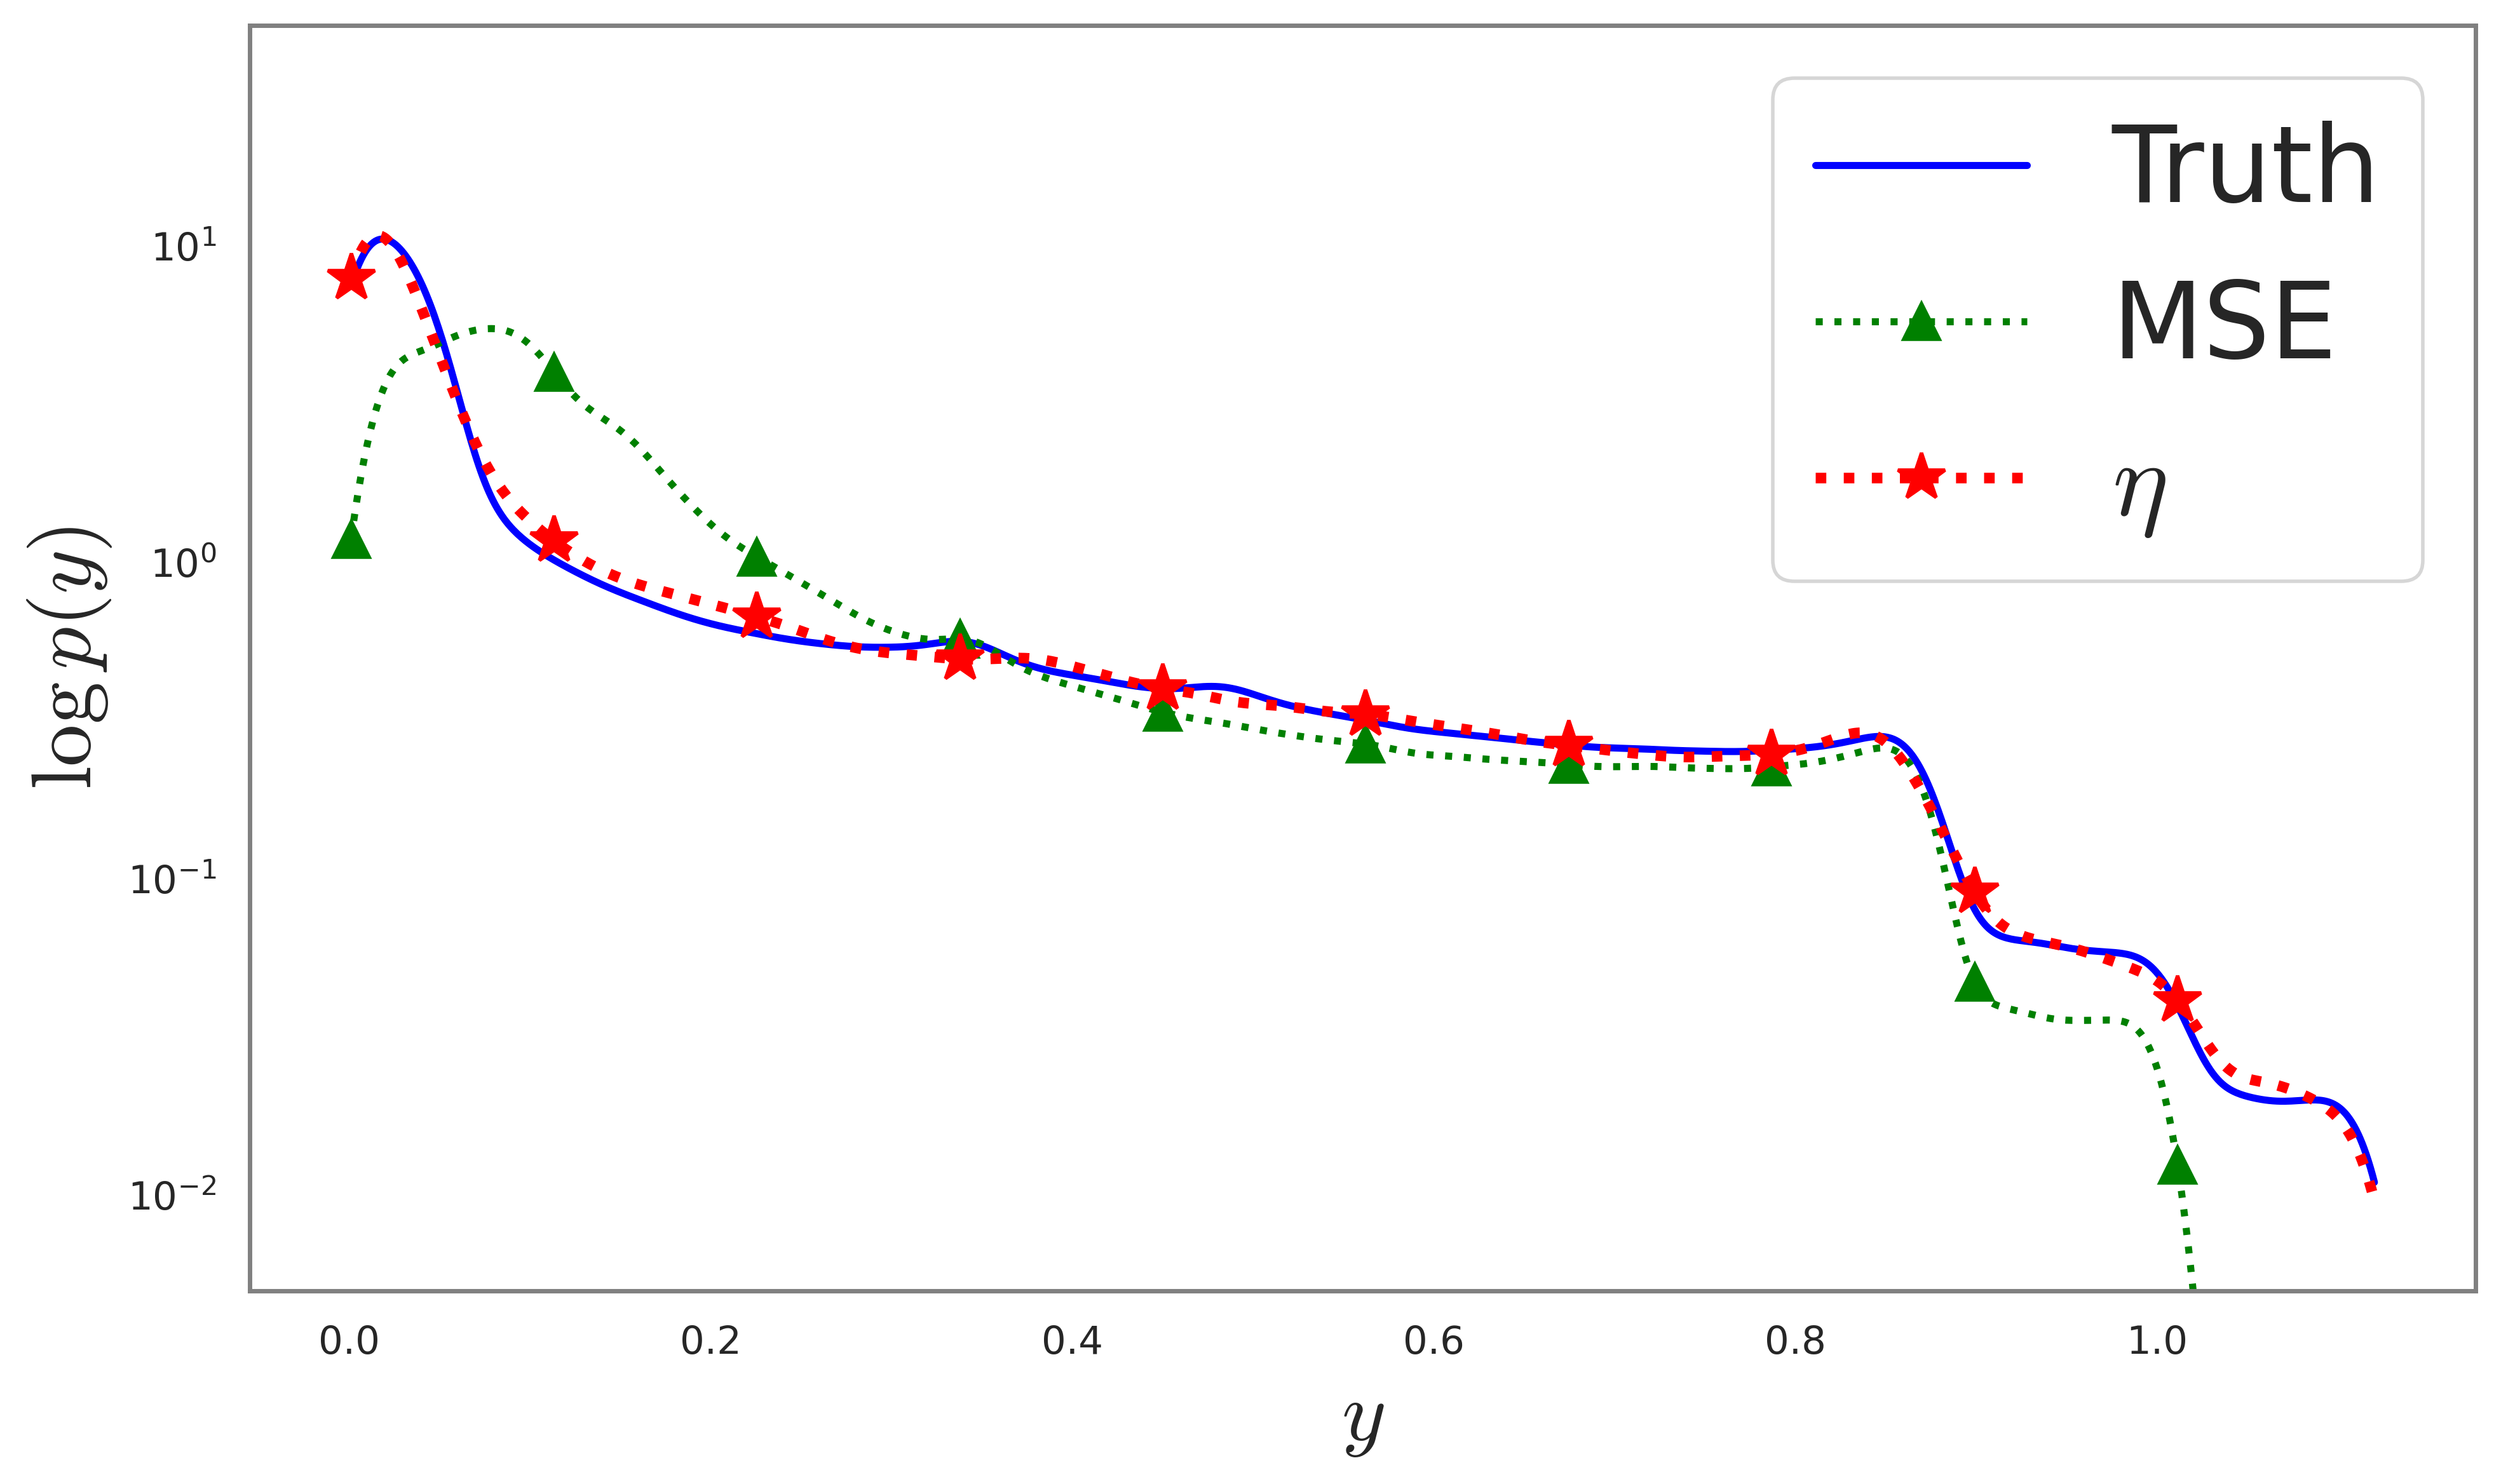

In [ ]:
seed_list = [27,28,50,63,64,83]
seed_list = [28,50,64]
seed_list = [28]
seed_idx = [1,2,5,7,8,12]
seed_idx = [1,2,4]
seed_idx = [0]
for i,seed in enumerate(seed_list):
    print('seed: ', seed_list[i])
    eta_eval_res = eta_eval_res_list[seed_idx[i]]
    fig1, ax1 = plt.subplots(1,3,figsize=(18,4), dpi=400) 
    # Find global min and max for consistent color scale
    vmin = 0#min(torch.min(U1_GRID).item(), np.min(mse_eval_res.u1_grid).item())
    vmax = max(torch.max(U1_GRID).item(), np.max(mse_eval_res.u1_grid).item(), np.max(eta_eval_res.u1_grid).item())
    # Create contour plots with same levels and color scale
    contour_truth_1 = ax1[0].contour(X1,X2,U1_GRID, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
    ax1[0].set_title(r"Truth - $u_1(x_1,x_2)$", fontsize=24)
    ax1[0].set_xlabel(r"$x_1$", fontsize=18)
    ax1[0].set_ylabel(r"$x_2$", fontsize=18)
    ax1[0].plot(x_train[:,0], x_train[:,1], 'x', markersize=6, color='#333333', alpha=1, linewidth=2,
                    label=r'Training Data ($n$' + f' = {n_train})')
    ax1[0].set_xlim(-6,6)
    ax1[0].set_ylim(-6,6)
    # ax1[0].axis('off')
    ax1[0].legend(prop={'size':12})
    contour2 = ax1[1].contour(X1,X2,mse_eval_res.u1_grid, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
    ax1[1].set_title(r"MSE - $u_1(x_1,x_2)$", fontsize=24)
    ax1[1].set_xlabel(r"$x_1$", fontsize=18)
    ax1[1].set_xlim(-6,6)
    ax1[1].set_ylim(-6,6)
    # ax1[1].axis('off')
    contour3 = ax1[2].contour(X1,X2,eta_eval_res.u1_grid, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
    ax1[2].set_title(r"$\eta$ - $u_1(x_1,x_2)$", fontsize=24)
    ax1[2].set_xlabel(r"$x_1$", fontsize=18)
    ax1[2].set_xlim(-6,6)
    ax1[2].set_ylim(-6,6)
    # ax1[2].axis('off')
    # Add a colorbar that applies to all plots
    fig1.colorbar(contour_truth_1, ax=ax1, shrink=1, pad=0.02)

    fig2, ax2 = plt.subplots(1,3,figsize=(18,4), dpi=400)
    # Find global min and max for consistent color scale
    vmin = 0#min(torch.min(U2_GRID).item(), np.min(mse_eval_res.u2_grid).item())
    vmax = max(torch.max(U2_GRID).item(), np.max(mse_eval_res.u2_grid).item(), np.max(eta_eval_res.u2_grid).item())
    # Create contour plots with same levels and color scale
    contour_truth_2 = ax2[0].contour(X1,X2,U2_GRID, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
    ax2[0].set_title(r"Truth - $u_2(x_1,x_2)$", fontsize=24)
    ax2[0].set_xlabel(r"$x_1$", fontsize=18)
    ax2[0].set_ylabel(r"$x_2$", fontsize=18)
    ax2[0].plot(x_train[:,0], x_train[:,1], 'x', markersize=6, color='#333333', alpha=1, linewidth=2,
                    label=r'Training Data ($n$' + f' = {n_train})')
    ax2[0].set_xlim(-6,6)
    ax2[0].set_ylim(-6,6)
#     ax2[0].axis('off')
    ax2[0].legend(prop={'size':12})
    contour2 = ax2[1].contour(X1,X2,mse_eval_res.u2_grid, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
    ax2[1].set_title(r"MSE - $u_2(x_1,x_2)$", fontsize=24)
    ax2[1].set_xlabel(r"$x_1$", fontsize=18)
    ax2[1].set_xlim(-6,6)
    ax2[1].set_ylim(-6,6)
#     ax2[1].axis('off')
    contour3 = ax2[2].contour(X1,X2,eta_eval_res.u2_grid, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
    ax2[2].set_title(r"$\eta$ - $u_2(x_1,x_2)$", fontsize=24)
    ax2[2].set_xlabel(r"$x_1$", fontsize=18)
    ax2[2].set_xlim(-6,6)
    ax2[2].set_ylim(-6,6)
#     ax2[2].axis('off')
    # Add a colorbar that applies to all plots
    fig2.colorbar(contour_truth_2, ax=ax2, shrink=1, pad=0.02)

    y_eta, py_eta, y_eta_pdf = get_data_pdf(eta_eval_res.y_samples, Y, None)
    fig3 = plt.figure(figsize=(10,6), dpi=400)
    plt.plot(y_true, py_true, label=r"Truth", color='blue', linestyle='-', linewidth=2)
    plt.plot(y_mse, py_mse, label=r"MSE", color='green', linestyle=':', 
            marker='^', markevery=100, linewidth=2, markersize=10)
    plt.plot(y_eta, py_eta, label=r"$\eta$", color='red', linestyle=':', 
            marker='*', markersize=14, markevery=100, linewidth=3)
    plt.xlabel(r"$y$", fontsize=24)
    plt.ylabel(r"$\log{p(y)}$", fontsize=24)
    plt.yscale('log')
    plt.ylim(5e-3, 50)
    plt.legend(prop={'size': 30})
    plt.tight_layout()
    plt.show()

    # fig4, ax4 = plt.subplots(2,1,figsize=(6,10), dpi=400)
    # ax4[0].contour(X1,X2,eta_eval_res.u1_grid, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
    # ax4[1].contour(X1,X2,eta_eval_res.u2_grid, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
    # assert 0==1

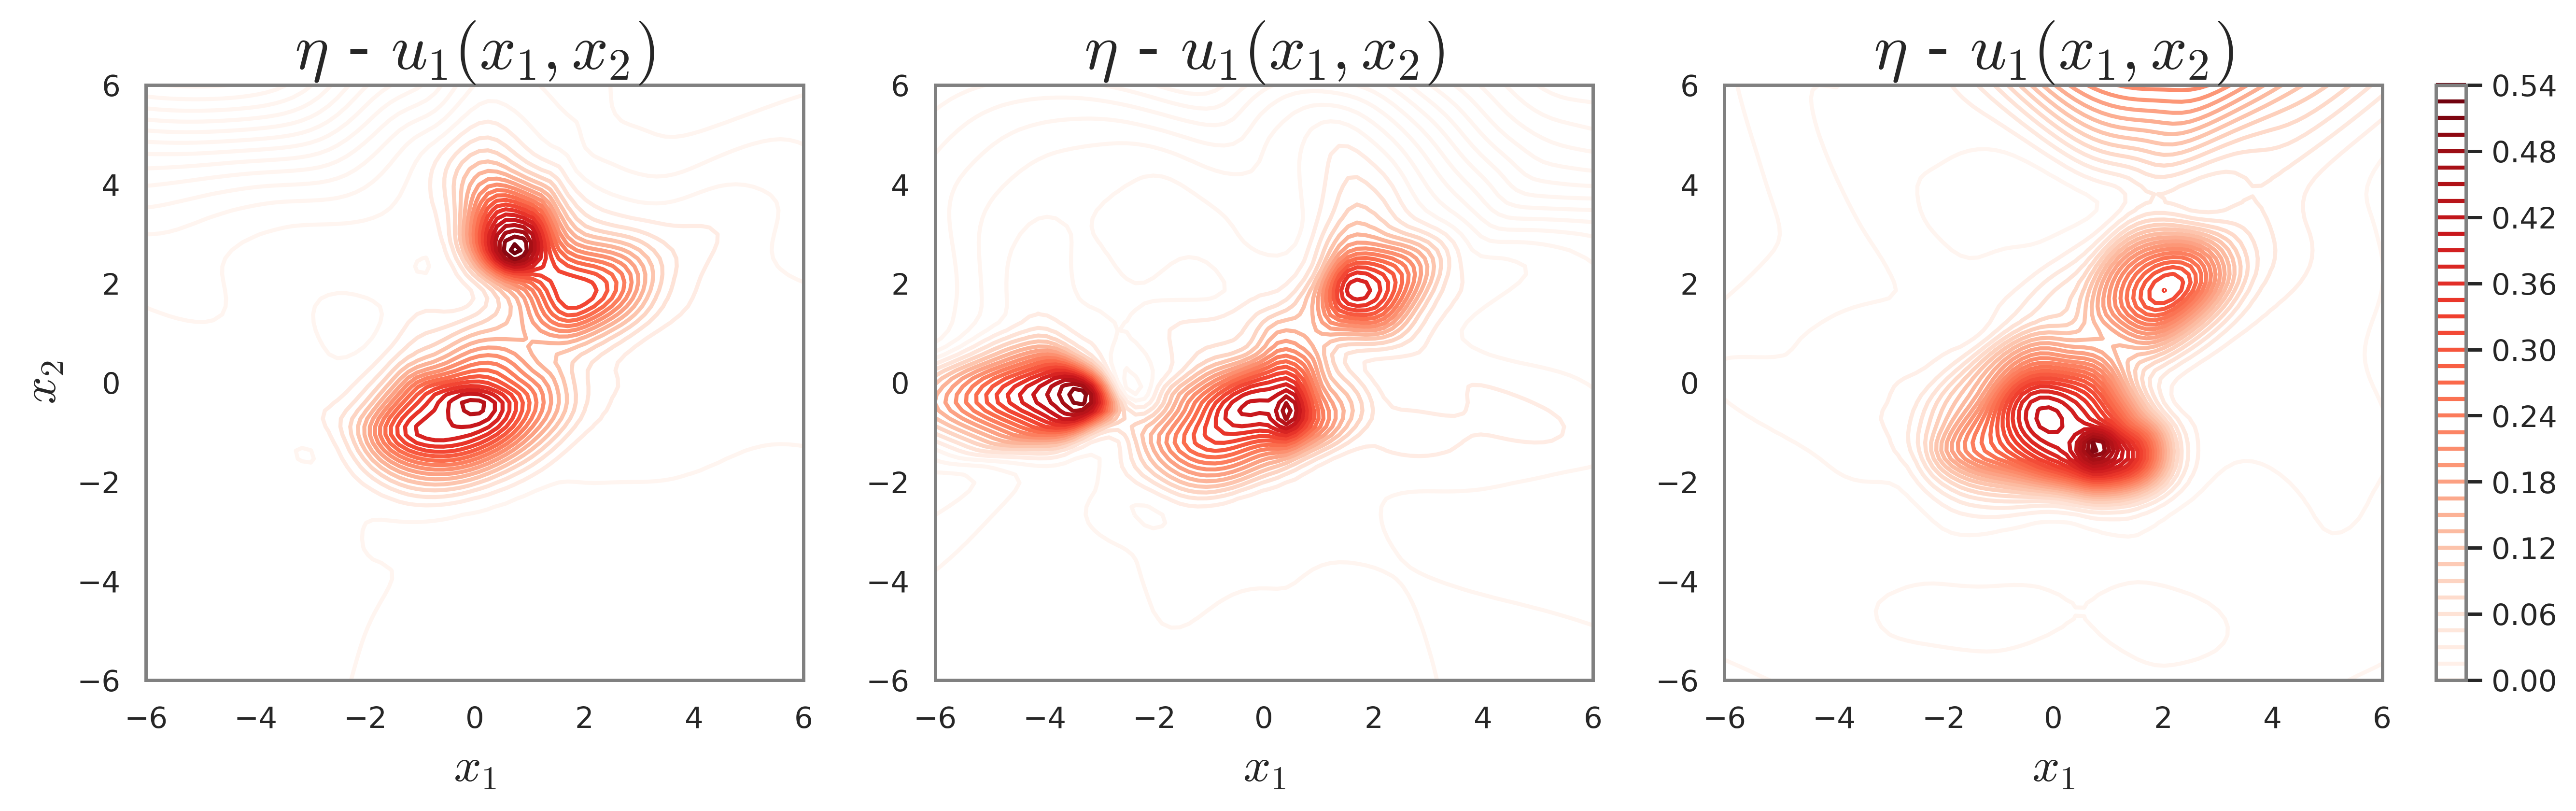

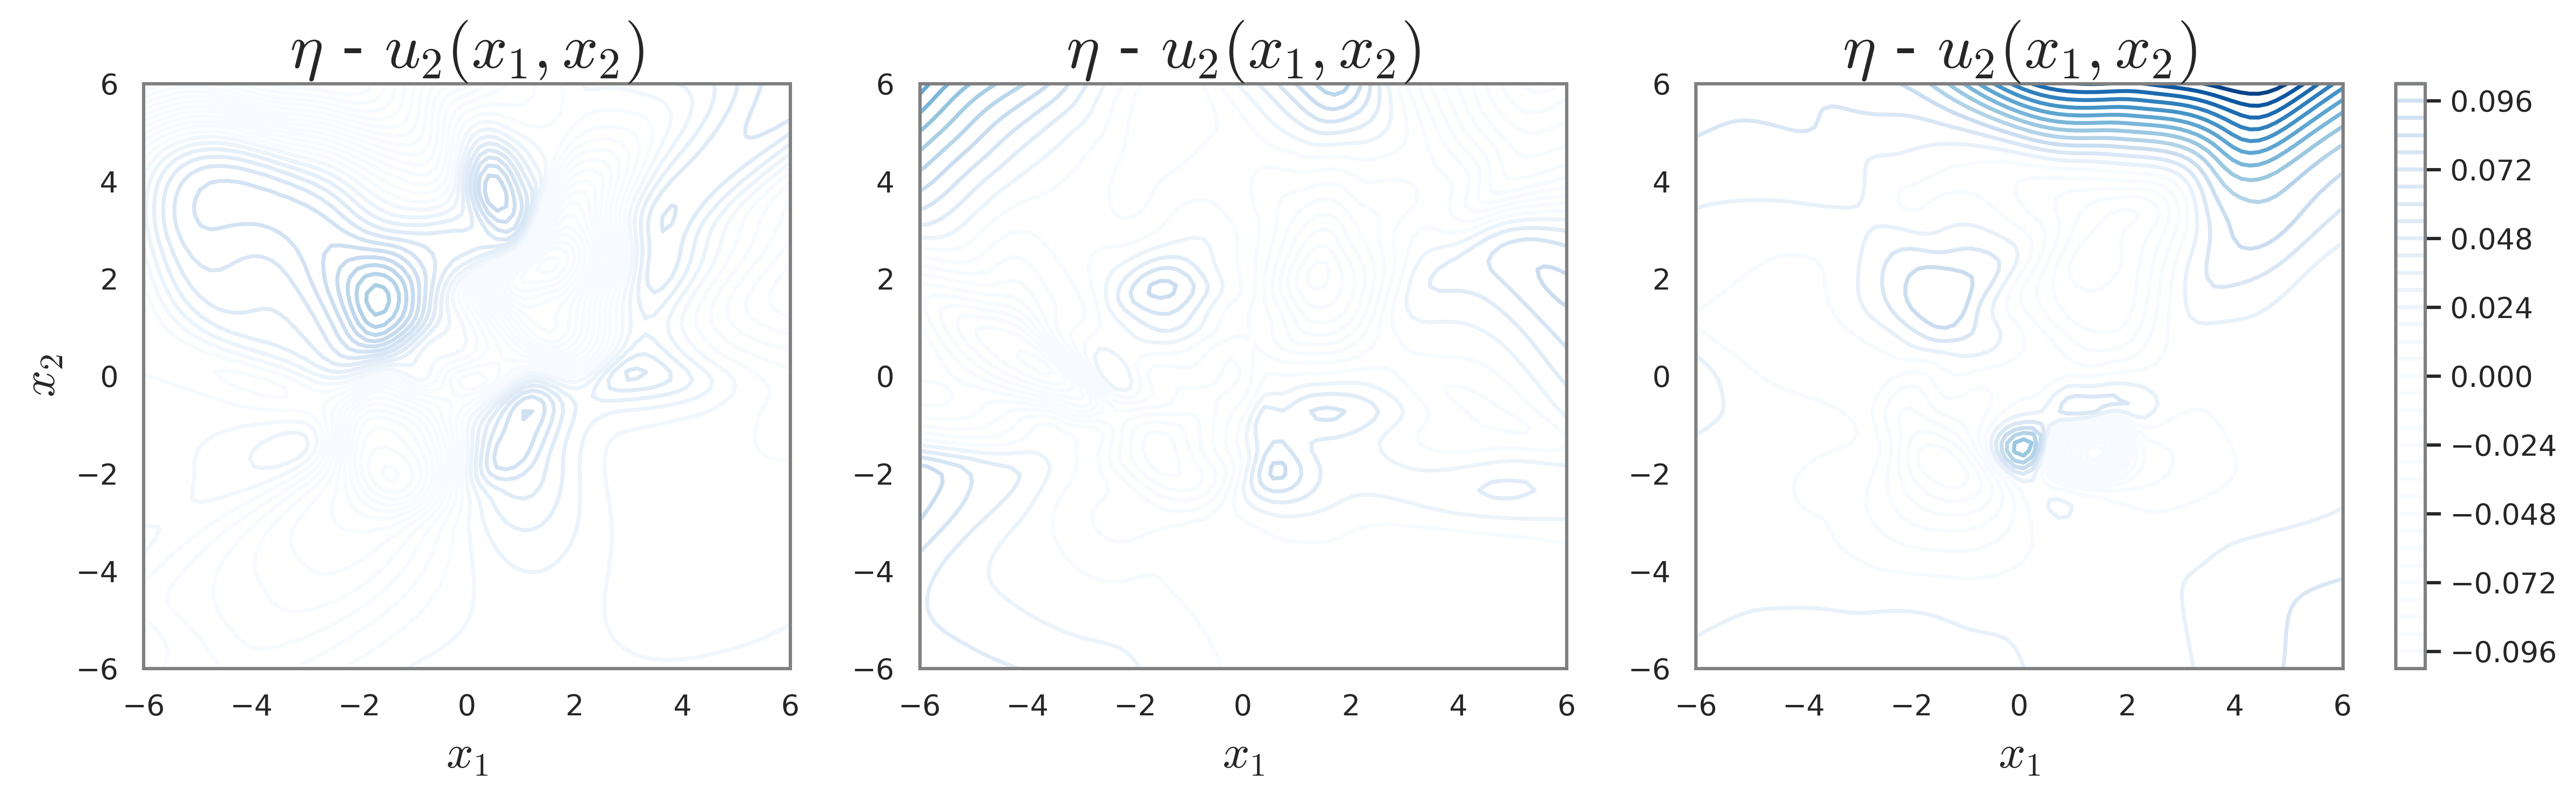

In [78]:
fig1, ax1 = plt.subplots(1,3,figsize=(18,4), dpi=400) 
# Find global min and max for consistent color scale
vmin = 0#min(torch.min(U1_GRID).item(), np.min(mse_eval_res.u1_grid).item())
vmax = max(np.max(eta_eval_res_list[2].u1_grid).item(), np.max(eta_eval_res_list[5].u1_grid).item(), np.max(eta_eval_res_list[8].u1_grid).item())
# Create contour plots with same levels and color scale
contour1 = ax1[0].contour(X1,X2,eta_eval_res_list[2].u1_grid, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
ax1[0].set_title(r"$\eta$ - $u_1(x_1,x_2)$", fontsize=24)
ax1[0].set_xlabel(r"$x_1$", fontsize=18)
ax1[0].set_ylabel(r"$x_2$", fontsize=18)
ax1[0].set_xlim(-6,6)
ax1[0].set_ylim(-6,6)
contour2 = ax1[1].contour(X1,X2,eta_eval_res_list[5].u1_grid, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
ax1[1].set_title(r"$\eta$ - $u_1(x_1,x_2)$", fontsize=24)
ax1[1].set_xlabel(r"$x_1$", fontsize=18)
ax1[1].set_xlim(-6,6)
ax1[1].set_ylim(-6,6)
contour3 = ax1[2].contour(X1,X2,eta_eval_res_list[8].u1_grid, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
ax1[2].set_title(r"$\eta$ - $u_1(x_1,x_2)$", fontsize=24)
ax1[2].set_xlabel(r"$x_1$", fontsize=18)
ax1[2].set_xlim(-6,6)
ax1[2].set_ylim(-6,6)
# Add a colorbar that applies to all plots
fig1.colorbar(contour_truth_1, ax=ax1, shrink=1, pad=0.02)

fig2, ax2 = plt.subplots(1,3,figsize=(18,4), dpi=400)
# Find global min and max for consistent color scale
vmin = 0#min(torch.min(U2_GRID).item(), np.min(mse_eval_res.u2_grid).item())
vmax = max(np.max(eta_eval_res_list[0].u2_grid).item(), np.max(eta_eval_res_list[2].u2_grid).item(), np.max(eta_eval_res_list[6].u2_grid).item())
# Create contour plots with same levels and color scale
contour2 = ax2[0].contour(X1,X2,eta_eval_res_list[2].u2_grid, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
ax2[0].set_title(r"$\eta$ - $u_2(x_1,x_2)$", fontsize=24)
ax2[0].set_xlabel(r"$x_1$", fontsize=18)
ax2[0].set_ylabel(r"$x_2$", fontsize=18)
ax2[0].set_xlim(-6,6)
ax2[0].set_ylim(-6,6)
contour2 = ax2[1].contour(X1,X2,eta_eval_res_list[5].u2_grid, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
ax2[1].set_title(r"$\eta$ - $u_2(x_1,x_2)$", fontsize=24)
ax2[1].set_xlabel(r"$x_1$", fontsize=18)
ax2[1].set_xlim(-6,6)
ax2[1].set_ylim(-6,6)
contour3 = ax2[2].contour(X1,X2,eta_eval_res_list[8].u2_grid, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
ax2[2].set_title(r"$\eta$ - $u_2(x_1,x_2)$", fontsize=24)
ax2[2].set_xlabel(r"$x_1$", fontsize=18)
ax2[2].set_xlim(-6,6)
ax2[2].set_ylim(-6,6)
# Add a colorbar that applies to all plots
fig2.colorbar(contour_truth_2, ax=ax2, shrink=1, pad=0.02)

# y_eta, py_eta, y_eta_pdf = get_data_pdf(eta_eval_res.y_samples, Y, None)
# fig3 = plt.figure(figsize=(10,6), dpi=400)
# plt.plot(y_true, py_true, label=r"Truth", color='blue', linestyle='-', linewidth=2)
# plt.plot(y_mse, py_mse, label=r"MSE", color='green', linestyle=':', 
#         marker='^', markevery=100, linewidth=2, markersize=10)
# plt.plot(y_eta, py_eta, label=r"$\eta$", color='red', linestyle=':', 
#         marker='*', markersize=14, markevery=100, linewidth=3)
# plt.xlabel(r"$y$", fontsize=24)
# plt.ylabel(r"$\log{p(y)}$", fontsize=24)
# plt.yscale('log')
# plt.ylim(5e-3, 50)
# plt.legend(prop={'size': 30})
# plt.tight_layout()
# plt.show()

# fig4, ax4 = plt.subplots(2,1,figsize=(6,10), dpi=400)
# ax4[0].contour(X1,X2,eta_eval_res.u1_grid, levels=36, cmap='Reds', vmin=vmin, vmax=vmax)
# ax4[1].contour(X1,X2,eta_eval_res.u2_grid, levels=36, cmap='Blues', vmin=vmin, vmax=vmax)
# assert 0==1

# Revision experiment: spatial uncertainty across η-estimator realizations

The purpose of this revision diagnostic is not to prove exact recovery of the unobserved extreme location or component-wise allocation. The purpose is to quantify residual spatial uncertainty under scalar observable calibration. For each available state-map η-estimator, the scalar diagnostic uses the existing observable
$$
y_\eta^{(k)}(z)=g(u_\eta^{(k)}(z))=2|u_{1,\eta}^{(k)}(z)|+\frac12|u_{2,\eta}^{(k)}(z)|.
$$
On the existing contour grid $\mathcal G_E=\mathcal G$, we compute
$$
\widehat z_k=\arg\max_{z\in\mathcal G_E} y_\eta^{(k)}(z),\qquad
\widehat a_k=\max_{z\in\mathcal G_E} y_\eta^{(k)}(z),
$$
and compare these with the true grid-level extreme location and amplitude $(z_\star,a_\star)$. The location/amplitude summaries are
$$
V_{\rm loc}=\frac1K\sum_{k=1}^K\|\widehat z_k-\bar z\|_2^2,
\quad
E_{\rm loc}=\frac1K\sum_{k=1}^K\|\widehat z_k-z_\star\|_2,
\quad
E_{\rm amp}=\frac1K\sum_{k=1}^K\frac{|\widehat a_k-a_\star|}{|a_\star|}.
$$
The component-wise grid errors are
$$
{\rm rRMSE}_{u_j}=\frac{\left[\sum_{z\in\mathcal G}(u_{j,\eta}(z)-u_j(z))^2\right]^{1/2}}{\left[\sum_{z\in\mathcal G}u_j(z)^2\right]^{1/2}},\qquad j=1,2.
$$


The following code reuses available η realizations, optionally trains missing seeds if the flag is enabled, computes observable-level spatial uncertainty, and reports full-grid plus tail-neighborhood component rRMSE. The tail neighborhood is the true-observable exceedance region $\{z:y(z)>t\}$ at the empirical 0.99 observable quantile.


In [11]:
from IPython.display import display
import pandas as pd
from models import FCNN
from train_utils import generate_2d_gaussian, grf_pretrain, train_eta_xuy
from test_utils import eval_result_2d
from revision_utils import tail_w1_quantile, to_numpy

REVISION_K_TARGET = 20
RUN_MISSING_ETA_REALIZATIONS = True
REVISION_SEED_POOL = [27, 28, 50, 63, 64, 83, 22, 25, 29, 32,
                      33, 38, 39, 40, 41, 43, 51, 54, 57, 58]

if 'eta_res_list' not in globals():
    eta_res_list = []
if 'eta_eval_res_list' not in globals():
    eta_eval_res_list = []
if 'seed_list' not in globals():
    seed_list = []

available_eta_eval_res = [res for res in eta_eval_res_list if hasattr(res, 'u1_grid') and hasattr(res, 'u2_grid')]
seeds_already_recorded = list(seed_list[:len(available_eta_eval_res)])
missing_seeds = [s for s in REVISION_SEED_POOL if s not in seeds_already_recorded][:max(0, REVISION_K_TARGET - len(available_eta_eval_res))]

if missing_seeds and RUN_MISSING_ETA_REALIZATIONS:
    _device = device('all')
    pretrain_epochs = globals().get('pretrain_epochs', 1000)
    epochs = globals().get('epochs', 3000)
    batch_size = globals().get('batch_size', n_train)
    _lamb = globals().get('_lamb', 1.0)
    omega = globals().get('omega', 100)
    n_neurons = globals().get('n_neurons', 256)
    dimensions = globals().get('dimensions', [n_neurons, n_neurons, n_neurons])
    activation = globals().get('activation', 'psilu')
    indim = globals().get('indim', 2)
    outdim = globals().get('outdim', 2)
    init = globals().get('init', 'kaiming normal')
    optim = globals().get('optim', torch.optim.Adam)
    pretrain_u2 = globals().get('pretrain_u2', U2_GRID.unsqueeze(-1))
    for revision_seed in missing_seeds:
        global_seed(revision_seed)
        print("training revision seed:", revision_seed)
        eta_pretrain = FCNN(dimensions, activation, indim, outdim, init, False).to(_device)
        eta_pretrain = nn.DataParallel(eta_pretrain)
        gaussian_field, _ = generate_2d_gaussian(seed=revision_seed, sigma=0.3)
        pretrain_field = torch.cat((gaussian_field.unsqueeze(-1), pretrain_u2), dim=-1)
        pretrain_res = grf_pretrain(pretrain_field, eta_pretrain, pretrain_epochs,
                                    n_grid=50, grid_step=2, device=_device)
        eta_res = train_eta_xuy(pretrain_res.model, x_train, u_train, X, Y, y, quantiles,
                                optim, epochs, batch_size, _device, _lamb, omega)
        eta_eval_res = eval_result_2d(eta_res, GRIDS, X, y, best_model=True)
        eta_res_list.append(eta_res)
        eta_eval_res_list.append(eta_eval_res)
        available_eta_eval_res.append(eta_eval_res)
        seeds_already_recorded.append(revision_seed)
        seed_list.append(revision_seed)
elif missing_seeds:
    print(f"Using {len(available_eta_eval_res)} available η realization(s). Set RUN_MISSING_ETA_REALIZATIONS=True to extend to K={REVISION_K_TARGET}.")
else:
    print(f"Using {len(available_eta_eval_res)} available η realization(s); target K={REVISION_K_TARGET} is already met or no seeds remain.")

available_eta_eval_res = available_eta_eval_res[:REVISION_K_TARGET]
seeds_used = seeds_already_recorded[:len(available_eta_eval_res)]
K_revision = len(available_eta_eval_res)
if K_revision == 0:
    raise RuntimeError("No η realizations are available for the revision diagnostic.")

grid_points = to_numpy(GRIDS)
X1_np = to_numpy(X1)
X2_np = to_numpy(X2)
U1_true = to_numpy(U1_GRID)
U2_true = to_numpy(U2_GRID)
Y_true_grid = 2 * np.abs(U1_true) + 0.5 * np.abs(U2_true)
true_flat = Y_true_grid.reshape(-1)
true_argmax = int(np.argmax(true_flat))
z_star = grid_points[true_argmax]
a_star = float(true_flat[true_argmax])
revision_extreme_threshold = float(np.quantile(to_numpy(Y).reshape(-1), 0.99))
tail_mask = Y_true_grid > revision_extreme_threshold

z_hats = []
a_hats = []
tail_w1_values = []
eta_observable_stack = []
component_rows = []
for seed_value, eta_eval_res in zip(seeds_used, available_eta_eval_res):
    u1_eta = to_numpy(eta_eval_res.u1_grid)
    u2_eta = to_numpy(eta_eval_res.u2_grid)
    y_eta_grid = 2 * np.abs(u1_eta) + 0.5 * np.abs(u2_eta)
    eta_observable_stack.append(y_eta_grid)
    eta_argmax = int(np.argmax(y_eta_grid.reshape(-1)))
    z_hats.append(grid_points[eta_argmax])
    a_hats.append(float(y_eta_grid.reshape(-1)[eta_argmax]))
    tail_w1_values.append(tail_w1_quantile(eta_eval_res.y_samples, Y, quantiles))

    u1_rrmse = np.sqrt(np.sum((u1_eta - U1_true) ** 2)) / (np.sqrt(np.sum(U1_true ** 2)) + 1e-12)
    u2_rrmse = np.sqrt(np.sum((u2_eta - U2_true) ** 2)) / (np.sqrt(np.sum(U2_true ** 2)) + 1e-12)
    row = {"seed": seed_value, "rRMSE_u1_grid": u1_rrmse, "rRMSE_u2_grid": u2_rrmse}
    if np.any(tail_mask):
        row["rRMSE_u1_tail_neighborhood"] = np.sqrt(np.sum((u1_eta[tail_mask] - U1_true[tail_mask]) ** 2)) / (np.sqrt(np.sum(U1_true[tail_mask] ** 2)) + 1e-12)
        row["rRMSE_u2_tail_neighborhood"] = np.sqrt(np.sum((u2_eta[tail_mask] - U2_true[tail_mask]) ** 2)) / (np.sqrt(np.sum(U2_true[tail_mask] ** 2)) + 1e-12)
    component_rows.append(row)

z_hats = np.asarray(z_hats)
a_hats = np.asarray(a_hats)
z_bar = z_hats.mean(axis=0)
V_loc = float(np.mean(np.sum((z_hats - z_bar) ** 2, axis=1)))
E_loc = float(np.mean(np.linalg.norm(z_hats - z_star, axis=1)))
E_amp = float(np.mean(np.abs(a_hats - a_star) / (abs(a_star) + 1e-12)))
component_df = pd.DataFrame(component_rows)

revision_spatial_uncertainty_df_2d = pd.DataFrame([{
    "K": K_revision,
    "target_K": REVISION_K_TARGET,
    "seeds_used": seeds_used,
    "threshold_t": revision_extreme_threshold,
    "tail_neighborhood_grid_cells": int(np.sum(tail_mask)),
    "z_star_x1": z_star[0],
    "z_star_x2": z_star[1],
    "z_bar_x1": z_bar[0],
    "z_bar_x2": z_bar[1],
    "V_loc": V_loc,
    "E_loc": E_loc,
    "a_star": a_star,
    "a_hat_mean": float(a_hats.mean()),
    "a_hat_std": float(a_hats.std(ddof=1)) if K_revision > 1 else 0.0,
    "E_amp": E_amp,
    "tail_W1_Q_mean": float(np.mean(tail_w1_values)),
    "tail_W1_Q_std": float(np.std(tail_w1_values, ddof=1)) if K_revision > 1 else 0.0,
    "mean_rRMSE_u1_grid": float(component_df["rRMSE_u1_grid"].mean()),
    "mean_rRMSE_u2_grid": float(component_df["rRMSE_u2_grid"].mean()),
    "mean_rRMSE_u1_tail_neighborhood": float(component_df.get("rRMSE_u1_tail_neighborhood", pd.Series([np.nan])).mean()),
    "mean_rRMSE_u2_tail_neighborhood": float(component_df.get("rRMSE_u2_tail_neighborhood", pd.Series([np.nan])).mean()),
}])

display(revision_spatial_uncertainty_df_2d)
display(component_df)


training revision seed: 27


100%|██████████| 3000/3000 [02:00<00:00, 24.89it/s]


training revision seed: 28


100%|██████████| 3000/3000 [02:01<00:00, 24.62it/s]


training revision seed: 50


...

100%|██████████| 3000/3000 [02:01<00:00, 24.75it/s]


training revision seed: 58


100%|██████████| 3000/3000 [02:01<00:00, 24.64it/s]


,K,target_K,seeds_used,threshold_t,tail_neighborhood_grid_cells,z_star_x1,z_star_x2,z_bar_x1,z_bar_x2,V_loc,...,a_star,a_hat_mean,a_hat_std,E_amp,tail_W1_Q_mean,tail_W1_Q_std,mean_rRMSE_u1_grid,mean_rRMSE_u2_grid,mean_rRMSE_u1_tail_neighborhood,mean_rRMSE_u2_tail_neighborhood
0,20,20,"[27, 28, 50, 63, 64, 83, 22, 25, 29, 32, 33, 3...",0.886123,36,2.020202,-2.020202,0.759596,-0.517172,38.76881,...,1.117031,1.100402,0.030055,0.016095,0.002406,0.000707,1.294439,1.885438,0.728659,0.865856


,seed,rRMSE_u1_grid,rRMSE_u2_grid,rRMSE_u1_tail_neighborhood,rRMSE_u2_tail_neighborhood
0,27,1.445587,2.003794,0.825731,0.876814
1,28,1.030653,1.328201,0.746994,0.487644
2,50,2.140646,1.817616,0.777278,0.729328
3,63,0.824695,1.573498,0.764379,0.641629
4,64,0.507636,1.152222,0.524592,1.545832
5,83,1.498156,2.446048,0.315414,2.705876
6,22,1.199397,1.780621,0.773626,0.696633
7,25,1.260669,1.805472,0.732744,0.671163
8,29,1.817182,2.031290,0.766551,0.706151
9,32,1.454814,2.704053,0.773805,0.700490


The exceedance-probability map uses the scalar observable induced by the state predictions:
$$
\widehat p_\eta(z;t)=\frac1K\sum_{k=1}^K\mathbf 1\{g(u_\eta^{(k)}(z))>t\}.
$$
The same threshold $t$ as in the table is used in the map title.


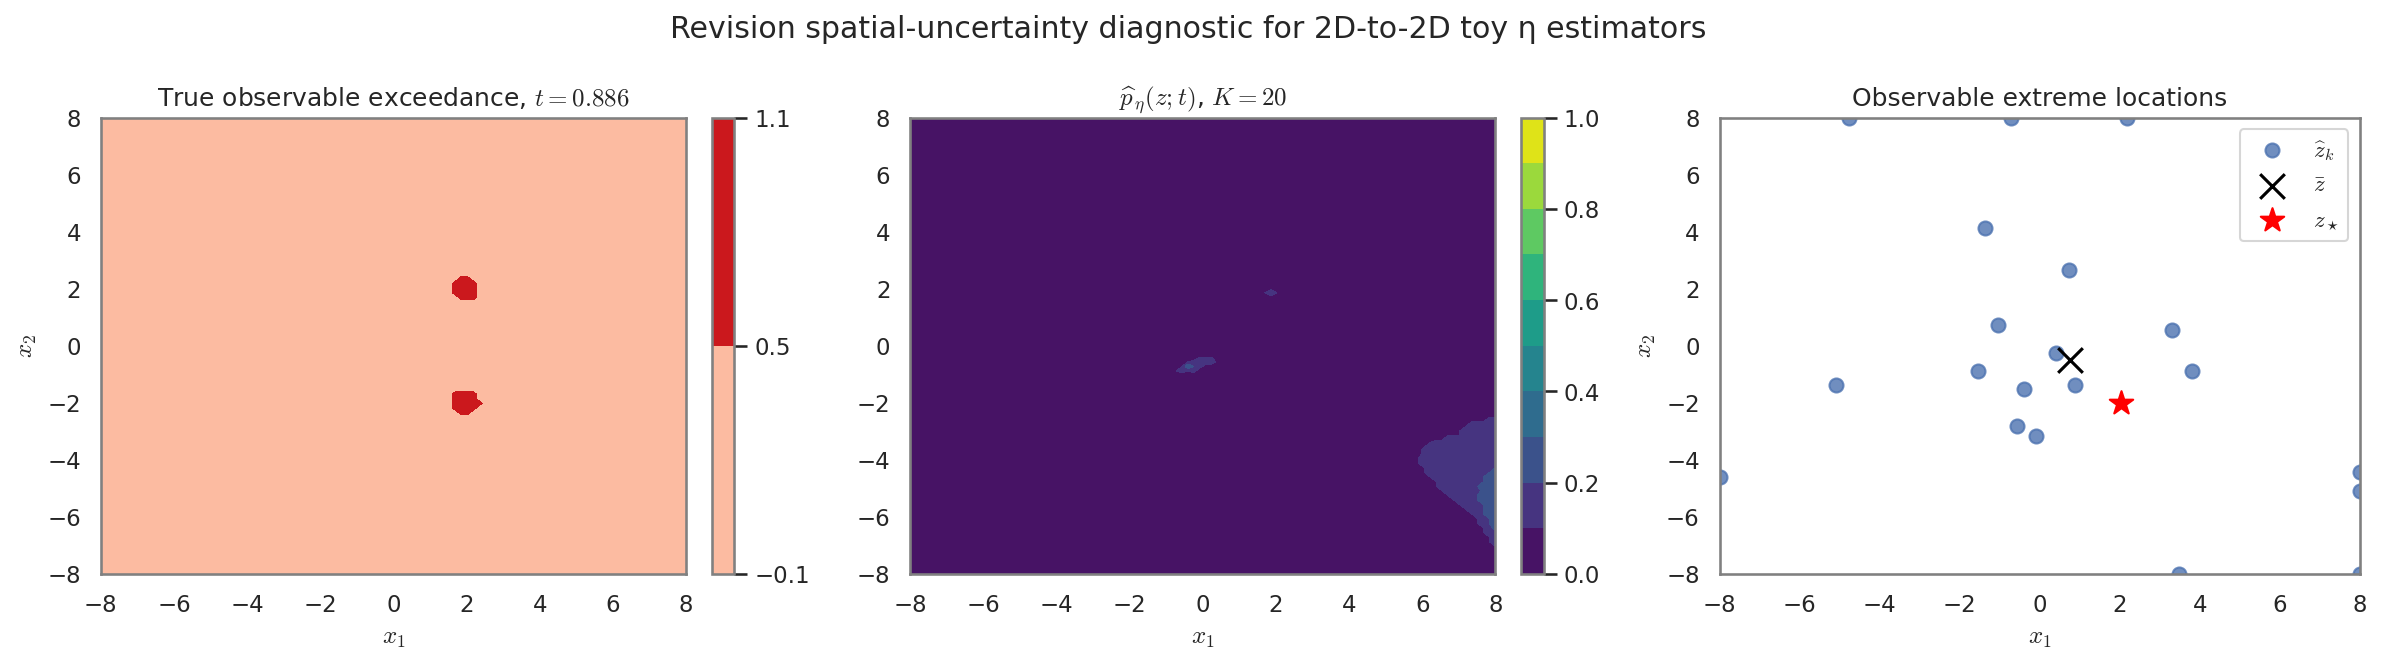

In [12]:
eta_observable_stack = np.stack(eta_observable_stack, axis=0)
p_eta = (eta_observable_stack > revision_extreme_threshold).mean(axis=0)
true_exceedance = (Y_true_grid > revision_extreme_threshold).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), dpi=150)
truth_img = axes[0].contourf(X1_np, X2_np, true_exceedance, levels=[-0.1, 0.5, 1.1], cmap='Reds')
axes[0].set_title(rf"True observable exceedance, $t={revision_extreme_threshold:.3f}$")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")
fig.colorbar(truth_img, ax=axes[0], fraction=0.046, pad=0.04)

prob_img = axes[1].contourf(X1_np, X2_np, p_eta, levels=np.linspace(0, 1, 11), cmap='viridis')
axes[1].set_title(rf"$\widehat p_\eta(z;t)$, $K={K_revision}$")
axes[1].set_xlabel(r"$x_1$")
fig.colorbar(prob_img, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].scatter(z_hats[:, 0], z_hats[:, 1], s=45, label=r"$\widehat z_k$", alpha=0.8)
axes[2].scatter([z_bar[0]], [z_bar[1]], s=140, marker='x', color='black', label=r"$\bar z$")
axes[2].scatter([z_star[0]], [z_star[1]], s=140, marker='*', color='red', label=r"$z_\star$")
axes[2].set_title("Observable extreme locations")
axes[2].set_xlabel(r"$x_1$")
axes[2].set_ylabel(r"$x_2$")
axes[2].set_xlim(float(np.min(X1_np)), float(np.max(X1_np)))
axes[2].set_ylim(float(np.min(X2_np)), float(np.max(X2_np)))
axes[2].legend()
fig.suptitle("Revision spatial-uncertainty diagnostic for 2D-to-2D toy η estimators")
fig.tight_layout()
plt.show()


# Revision documentation notes

This notebook corresponds to the paper's 2D-to-2D toy state-map experiment. The revision section added above displays observable-level spatial-uncertainty diagnostics, component-wise rRMSE diagnostics, an exceedance-probability map, and predicted extreme locations. No revision tables or figures are saved to disk; they are displayed directly in the notebook. Existing cells, outputs, saved SI figures, and experiment logic were not modified. Earlier exploratory multi-run plotting cells are preserved for backward reproducibility even where they overlap with the new diagnostics.
